# 04 — Baseline Linear Regression Model

Builds and compares two linear models to predict `tickets_scanned` for OHL home matches. 

Feature prep = Select, clean, and encode model inputs

Train/test split =  Time-based: train on 22/23–23/24, test on 24/25–25/26 

Plain Linear Regression — shows overfitting risk at this sample size 

Ridge Regularised linear model — shrinks coefficients to generalise better

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# --- Global plot style ---
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi':          130,
    'font.family':         'sans-serif',
    'font.size':           12,
    'axes.titlesize':      14,
    'axes.titleweight':    'bold',
    'axes.titlepad':       12,
    'axes.labelsize':      12,
    'axes.labelpad':       8,
    'xtick.labelsize':     11,
    'ytick.labelsize':     11,
    'legend.fontsize':     11,
    'legend.framealpha':   0.8,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
})

df = pd.read_csv('../data/cleaned/engineered_df.csv')
df['match_date'] = pd.to_datetime(df['match_date'])

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded: 71 rows, 41 columns


# 1 — Feature Preparation

## Features Used

| Feature | Type | Notes |
|--------|------|------|
| `opponent_grouped` | Categorical | 16 groups; singletons collapsed to "Other" in notebook 03 |
| `is_playoff` | Binary | Derived from `stage`: Conference League = 1, Regular Season = 0 |
| `last_h2h_result` | Categorical | W/D/L; 3 NaNs filled with "Unknown" |
| `kickoff_hour` | Numeric | Extracted from `kickoff_time_local` |
| `is_weekend` | Binary | 58 of 71 matches on a weekend — meaningful variation |
| `is_school_holiday_flanders` | Binary | 22 of 71 matches during school holidays |
| `has_promotion` | Binary | 26 of 71 matches had a ticketing promotion |
| `has_campaign` | Binary | Sustained marketing campaign flag — distinct from one-off promotions |
| `weather_score` | Numeric | Composite weather quality score |
| `avg_ohl_interest_7d` | Numeric | Google Trends 7-day average before match |
| `pre_match_interest_ratio` | Numeric | `avg_ohl_interest_7d / season_mean` — within-season relative buzz (Google Trends resets between seasons) |
| `pre_match_article_count` | Numeric | Press articles before match; 4 NaNs filled with median |
| `home_win_rate_last3` | Numeric | OHL home win rate over last 3 games; 1 NaN (first match) filled with 0 |
| `rolling_avg_attendance_last3` | Numeric | Average attendance over last 3 home games; 1 NaN (first match) filled with median |
| `ohl_season_points` | Numeric | OHL cumulative points before this match |
| `ohl_points_per_game` | Numeric | `ohl_season_points / matchday` — normalised form rate, comparable across the season |
| `matchday_normalized` | Numeric | `matchday / season_max_matchday` (0→1) — captures season phase; late-season games draw +40% more fans |
| `opp_ppg_vs_ohl` | Numeric | Opponent historical points-per-game vs OHL |
| `last_h2h_goal_margin` | Numeric | `last_h2h_ohl_goals − last_h2h_opponent_goals`; richer than W/D/L alone |

---

## Features Excluded and Why

| Feature | Reason Excluded |
|--------|----------------|
| `is_midweek` | Only 3 True out of 71 — too rare to estimate a reliable effect |
| `is_public_holiday` | Only 3 True out of 71 — too rare to estimate a reliable effect |
| `seasonpass_holders` | Constant within each season — removed in notebook 02 |
| `tickets_sold_total` | Not available before a match |
| `ohl_result`, `ohl_goals_ft`, `opponent_goals_ft` | Post-match data — would introduce data leakage |
| `weather_rain_mm`, `weather_windspeed_max_kmh`, etc. | Replaced by composite `weather_score` to avoid multicollinearity |
| `home_win_rate_last5` | `last3` is more recent; keeping both would be redundant |
| `promo_tickets_total` | Collinear with `has_promotion` |

In [52]:
model_df = df.copy()

# --- Derived features ---
model_df['kickoff_hour'] = pd.to_datetime(
    model_df['kickoff_time_local'], format='%H:%M:%S'
).dt.hour

model_df['is_playoff'] = (model_df['stage'] == 'Conference League Play-off Group').astype(int)

# --- Fill nulls ---
model_df['last_h2h_result'] = model_df['last_h2h_result'].fillna('Unknown')
model_df['home_win_rate_last3'] = model_df['home_win_rate_last3'].fillna(0)
model_df['pre_match_article_count'] = model_df['pre_match_article_count'].fillna(
    model_df['pre_match_article_count'].median()
)
# rolling_avg_attendance_last3: 1 NaN for the very first match — fill with overall median
model_df['rolling_avg_attendance_last3'] = model_df['rolling_avg_attendance_last3'].fillna(
    model_df['rolling_avg_attendance_last3'].median()
)

# --- Select columns ---
FEATURES_NUM = [
    # --- existing ---
    'kickoff_hour', 'is_playoff', 'is_weekend',
    'is_school_holiday_flanders', 'has_promotion',
    'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count',
    'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl',
    # --- new ---
    'rolling_avg_attendance_last3',  # strongest single predictor (r=0.475) — was engineered but unused
    'matchday_normalized',           # season phase (0→1); late-season draws +40% more fans
    'last_h2h_goal_margin',          # continuous H2H richness vs W/D/L only
    'ohl_points_per_game',           # normalised form rate; comparable across season
    'has_campaign',                  # marketing campaign flag; distinct from has_promotion
    'pre_match_interest_ratio',      # within-season relative Google Trends buzz
]
FEATURES_CAT = ['opponent_grouped', 'last_h2h_result']
TARGET = 'tickets_scanned'

# --- One-hot encode categoricals ---
encoded = pd.get_dummies(model_df[FEATURES_CAT], drop_first=True)

X = pd.concat([
    model_df[FEATURES_NUM].reset_index(drop=True),
    encoded.reset_index(drop=True)
], axis=1).astype(float)

y = model_df[TARGET].astype(float)

print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"\nFeature names ({len(X.columns)}):")
print(list(X.columns))

Feature matrix: 71 rows x 36 columns

Feature names (36):
['kickoff_hour', 'is_playoff', 'is_weekend', 'is_school_holiday_flanders', 'has_promotion', 'weather_score', 'avg_ohl_interest_7d', 'pre_match_article_count', 'home_win_rate_last3', 'ohl_season_points', 'opp_ppg_vs_ohl', 'rolling_avg_attendance_last3', 'matchday_normalized', 'last_h2h_goal_margin', 'ohl_points_per_game', 'has_campaign', 'pre_match_interest_ratio', 'opponent_grouped_Antwerp', 'opponent_grouped_Cercle Brugge', 'opponent_grouped_Club Brugge', 'opponent_grouped_Dender', 'opponent_grouped_Eupen', 'opponent_grouped_Genk', 'opponent_grouped_Gent', 'opponent_grouped_Kortrijk', 'opponent_grouped_Mechelen', 'opponent_grouped_Other', 'opponent_grouped_Sint-Truiden', 'opponent_grouped_Sporting Charleroi', 'opponent_grouped_Standard Liège', 'opponent_grouped_Union Saint-Gilloise', 'opponent_grouped_Westerlo', 'opponent_grouped_Zulte Waregem', 'last_h2h_result_L', 'last_h2h_result_Unknown', 'last_h2h_result_W']


## 2 — Time-based train / test split

A random split would leak future match information into the training set — the model would
effectively "see the future", making test performance unrealistically optimistic.

Instead we split by season:
- **Train:** 2022/23 + 2023/24 (37 matches)
- **Test:** 2024/25 + 2025/26 (34 matches)

In [53]:
train_mask = model_df['season'].isin(['2022/2023', '2023/2024', '2024/2025',])
test_mask  = model_df['season'].isin(['2025/2026'])
X_train, y_train = X[train_mask].reset_index(drop=True), y[train_mask].reset_index(drop=True)
X_test,  y_test  = X[test_mask].reset_index(drop=True),  y[test_mask].reset_index(drop=True)

print(f"Train: {len(X_train)} matches | Test: {len(X_test)} matches")
print(f"Train seasons: {model_df.loc[train_mask, 'season'].unique().tolist()}")
print(f"Test  seasons: {model_df.loc[test_mask,  'season'].unique().tolist()}")

Train: 57 matches | Test: 14 matches
Train seasons: ['2022/2023', '2023/2024', '2024/2025']
Test  seasons: ['2025/2026']


### ⚠ Known limitation — attendance distribution shift

The 2025/26 test season has structurally different attendance from all three training seasons:

| | Train (2022/23–2024/25) | Test (2025/26) |
|---|---|---|
| Mean attendance | ~7,122 | ~5,799 (−18%) |
| Std deviation | ~2,087 | ~1,088 (−48%) |

The test season is both lower on average and far more stable. Any model trained on the higher-variance 2022–2025 patterns will struggle to predict this regime — this is a fundamental data limitation, not a fixable modelling issue.

## 3 — OLS Linear Regression 
Ordinary Least Squares — the simplest linear model. Included here to show what happens without regularisation at this sample size (37 training rows, ~31 features).A large train/test R² gap below signals overfitting, which motivates the Ridge model 

In [54]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_train_pred_ols = ols.predict(X_train)
y_test_pred_ols  = ols.predict(X_test)

print("OLS fitted.")

OLS fitted.


## 4 — Evaluation metrics

| Metric | Meaning |
|---|---|
| **MAE** | Average absolute error in tickets — most intuitive |
| **RMSE** | Penalises large errors more heavily |
| **R²** | Proportion of attendance variance explained (1.0 = perfect, 0 = predicts mean) |

In [55]:
ols_metrics = pd.DataFrame({
    'MAE':  [mean_absolute_error(y_train, y_train_pred_ols),
             mean_absolute_error(y_test,  y_test_pred_ols)],
    'RMSE': [root_mean_squared_error(y_train, y_train_pred_ols),
             root_mean_squared_error(y_test,  y_test_pred_ols)],
    'R²':   [r2_score(y_train, y_train_pred_ols),
             r2_score(y_test,  y_test_pred_ols)],
}, index=['Train', 'Test'])

print("=== OLS metrics ===")
print(ols_metrics.round(3))

gap = ols_metrics.loc['Train', 'R²'] - ols_metrics.loc['Test', 'R²']
print(f"\nTrain-Test R² gap: {gap:.3f}  ", end="")
if gap > 0.15:
    print("(large gap — overfitting; Ridge regularisation applied in section 6)")
elif gap > 0.05:
    print("(moderate gap — acceptable for this sample size)")
else:
    print("(small gap — good generalisation)")

=== OLS metrics ===
            MAE      RMSE     R²
Train   746.183   908.248  0.807
Test   1315.942  1535.969 -1.145

Train-Test R² gap: 1.952  (large gap — overfitting; Ridge regularisation applied in section 6)


## 5 — Diagnostics

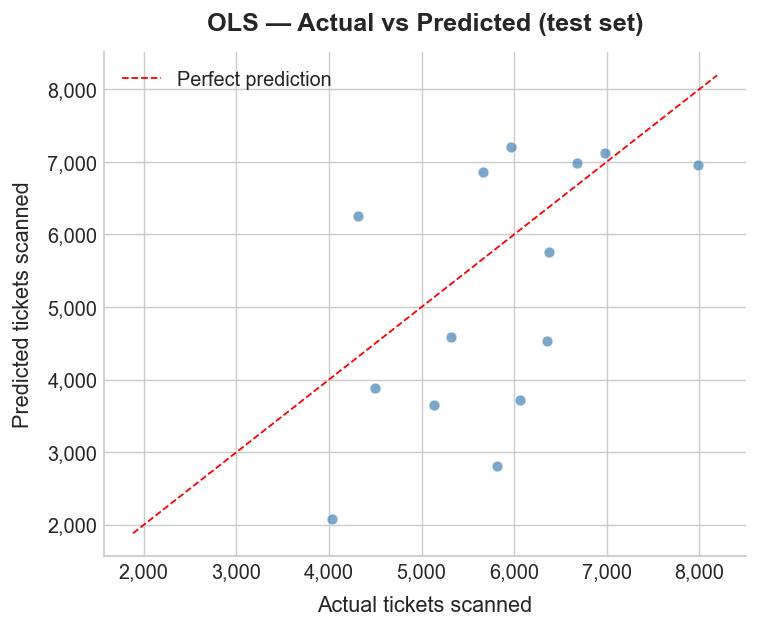

In [56]:
# --- OLS: Actual vs Predicted (test set) ---
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_test, y_test_pred_ols, color='steelblue', alpha=0.7, edgecolors='white', linewidths=0.4)

lims = [min(y_test.min(), y_test_pred_ols.min()) - 200,
        max(y_test.max(), y_test_pred_ols.max()) + 200]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')

ax.set_xlabel('Actual tickets scanned')
ax.set_ylabel('Predicted tickets scanned')
ax.set_title('OLS — Actual vs Predicted (test set)')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

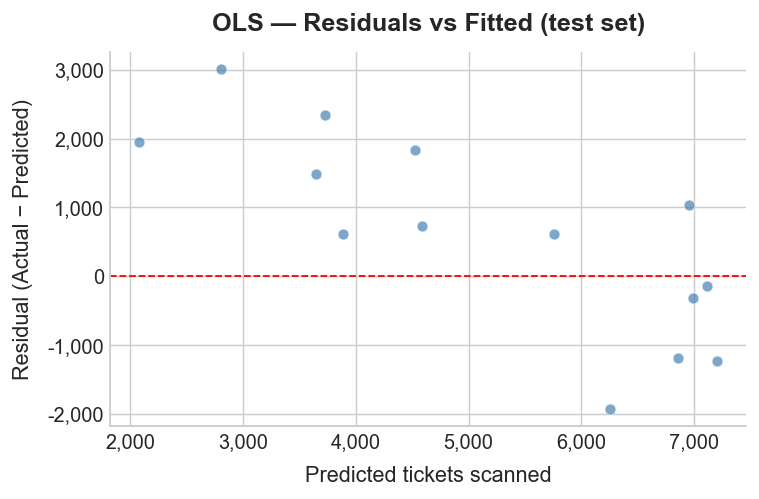

Residuals — mean: 627.9  std: 1454.7
Largest under-predictions: [-1934. -1234. -1195.]
Largest over-predictions:  [3004. 2336. 1953.]


In [57]:
# --- OLS: Residuals vs Fitted (test set) ---
residuals_ols = y_test - y_test_pred_ols

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(y_test_pred_ols, residuals_ols, color='steelblue', alpha=0.7, edgecolors='white', linewidths=0.4)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Predicted tickets scanned')
ax.set_ylabel('Residual (Actual − Predicted)')
ax.set_title('OLS — Residuals vs Fitted (test set)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

print(f"Residuals — mean: {residuals_ols.mean():.1f}  std: {residuals_ols.std():.1f}")
print(f"Largest under-predictions: {residuals_ols.nsmallest(3).values.round(0)}")
print(f"Largest over-predictions:  {residuals_ols.nlargest(3).values.round(0)}")

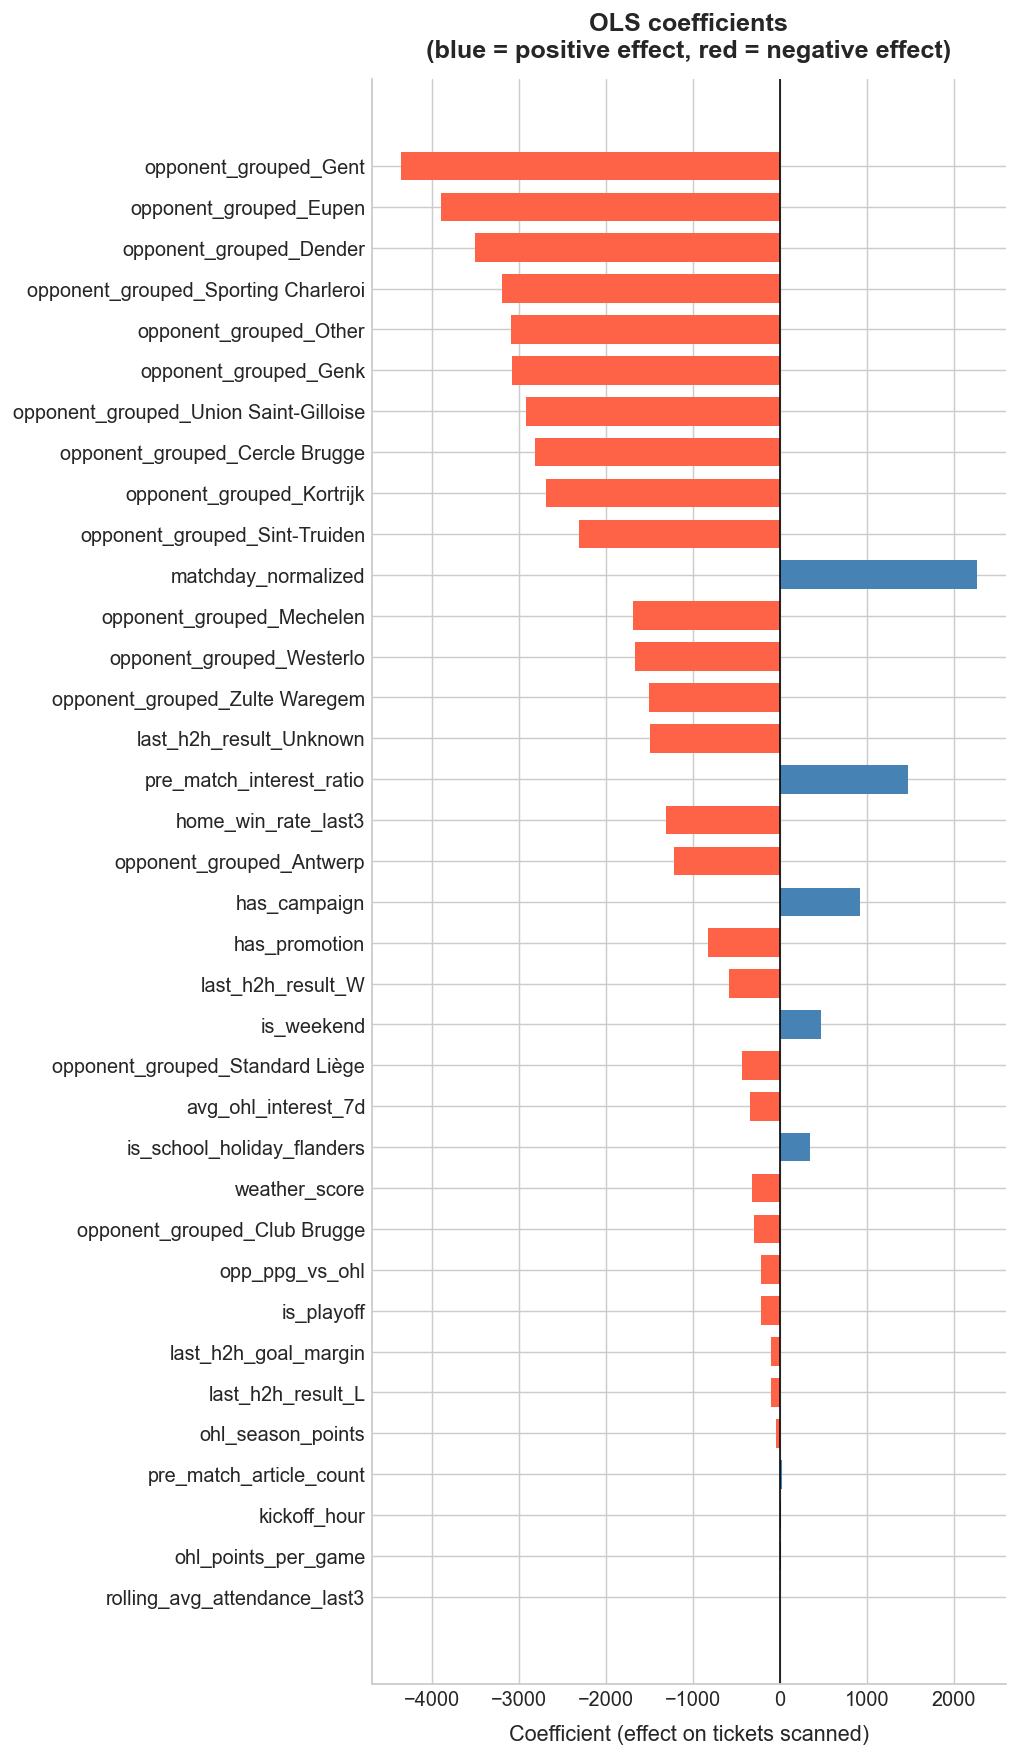

In [58]:
# --- OLS: Coefficient chart ---
coef_ols = pd.DataFrame({
    'feature': X.columns,
    'coefficient': ols.coef_
}).sort_values('coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(8, max(6, len(coef_ols) * 0.38)))
colours = ['steelblue' if c >= 0 else 'tomato' for c in coef_ols['coefficient']]
ax.barh(coef_ols['feature'], coef_ols['coefficient'], color=colours, height=0.7)
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Coefficient (effect on tickets scanned)')
ax.set_title('OLS coefficients\n(blue = positive effect, red = negative effect)')
plt.tight_layout()
plt.show()

<div style="font-size: 14px;">

## 6 — Ridge Regression

Ridge adds a penalty that shrinks all coefficients toward zero, preventing the model from over-relying on any single feature. This trades a small amount of training accuracy for much better generalisation on unseen matches.

`RidgeCV` automatically selects the best penalty strength (alpha) using generalised cross-validation, well-suited to small datasets as it uses every row for validation.

</div>

In [59]:
# Candidate alpha values — RidgeCV picks the best via generalised cross-validation
alphas = [0.01, 0.1, 1, 10, 50, 100, 200, 500, 1000]

ridge = RidgeCV(alphas=alphas)
ridge.fit(X_train, y_train)

y_train_pred_ridge = ridge.predict(X_train)
y_test_pred_ridge  = ridge.predict(X_test)

print(f"Best alpha selected by CV: {ridge.alpha_}")

Best alpha selected by CV: 1000.0


In [60]:
ridge_metrics = pd.DataFrame({
    'MAE':  [mean_absolute_error(y_train, y_train_pred_ridge),
             mean_absolute_error(y_test,  y_test_pred_ridge)],
    'RMSE': [root_mean_squared_error(y_train, y_train_pred_ridge),
             root_mean_squared_error(y_test,  y_test_pred_ridge)],
    'R²':   [r2_score(y_train, y_train_pred_ridge),
             r2_score(y_test,  y_test_pred_ridge)],
}, index=['Train', 'Test'])

print("=== Ridge metrics ===")
print(ridge_metrics.round(3))

gap = ridge_metrics.loc['Train', 'R²'] - ridge_metrics.loc['Test', 'R²']
print(f"\nTrain-Test R² gap: {gap:.3f}  ", end="")
if gap > 0.15:
    print("(large gap — still overfitting)")
elif gap > 0.05:
    print("(moderate gap — acceptable for this sample size)")
else:
    print("(small gap — good generalisation)")

=== Ridge metrics ===
            MAE      RMSE     R²
Train  1305.472  1622.020  0.385
Test   1022.239  1272.845 -0.473

Train-Test R² gap: 0.858  (large gap — still overfitting)


## 7 — Model comparison\n\nSide-by-side metrics, Actual vs Predicted, and coefficient charts for both models.

In [61]:
# --- Metrics comparison table ---
comparison = pd.concat(
    [ols_metrics.round(1), ridge_metrics.round(1)],
    keys=['OLS', 'Ridge']
)
print("=== OLS vs Ridge ===")
print(comparison)

=== OLS vs Ridge ===
                MAE    RMSE   R²
OLS   Train   746.2   908.2  0.8
      Test   1315.9  1536.0 -1.1
Ridge Train  1305.5  1622.0  0.4
      Test   1022.2  1272.8 -0.5


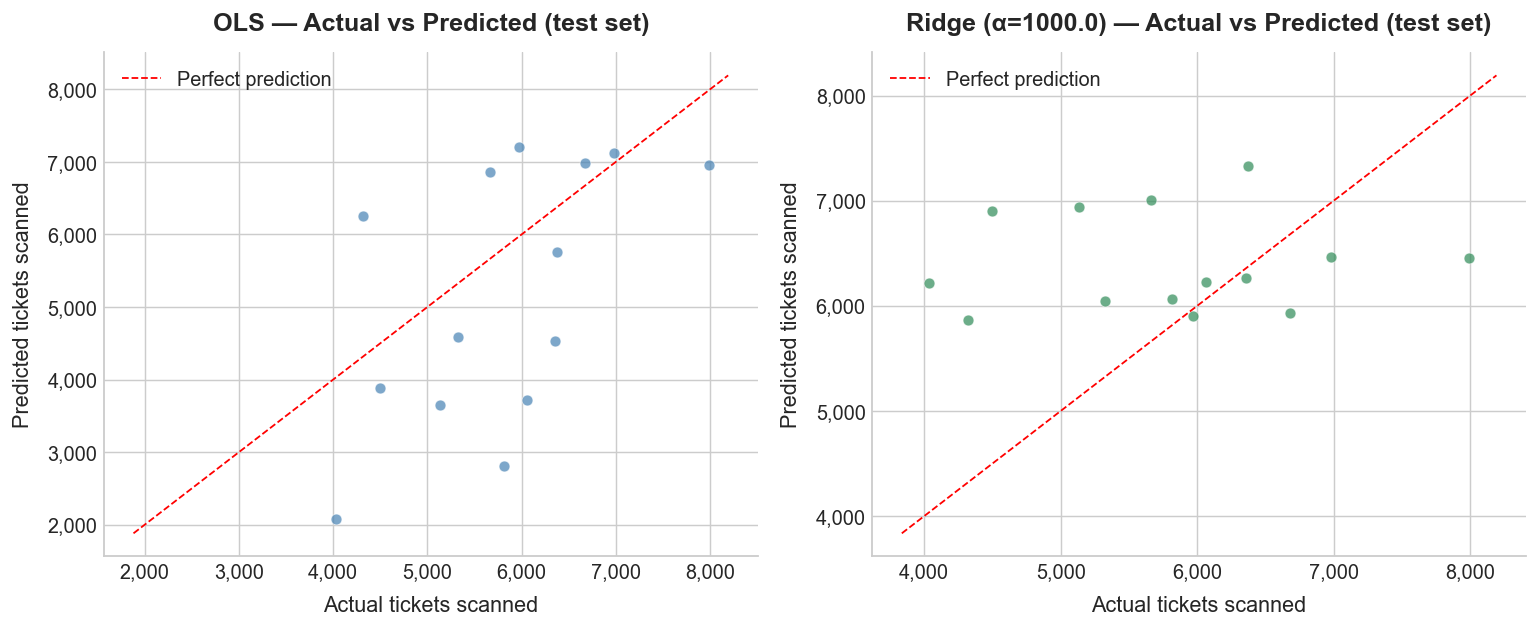

In [62]:
# --- Actual vs Predicted: OLS vs Ridge side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title, colour in zip(
    axes,
    [y_test_pred_ols, y_test_pred_ridge],
    ['OLS', f'Ridge (α={ridge.alpha_})'],
    ['steelblue', 'seagreen']
):
    ax.scatter(y_test, preds, color=colour, alpha=0.7, edgecolors='white', linewidths=0.4)
    lims = [min(y_test.min(), preds.min()) - 200, max(y_test.max(), preds.max()) + 200]
    ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual tickets scanned')
    ax.set_ylabel('Predicted tickets scanned')
    ax.set_title(f'{title} — Actual vs Predicted (test set)')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

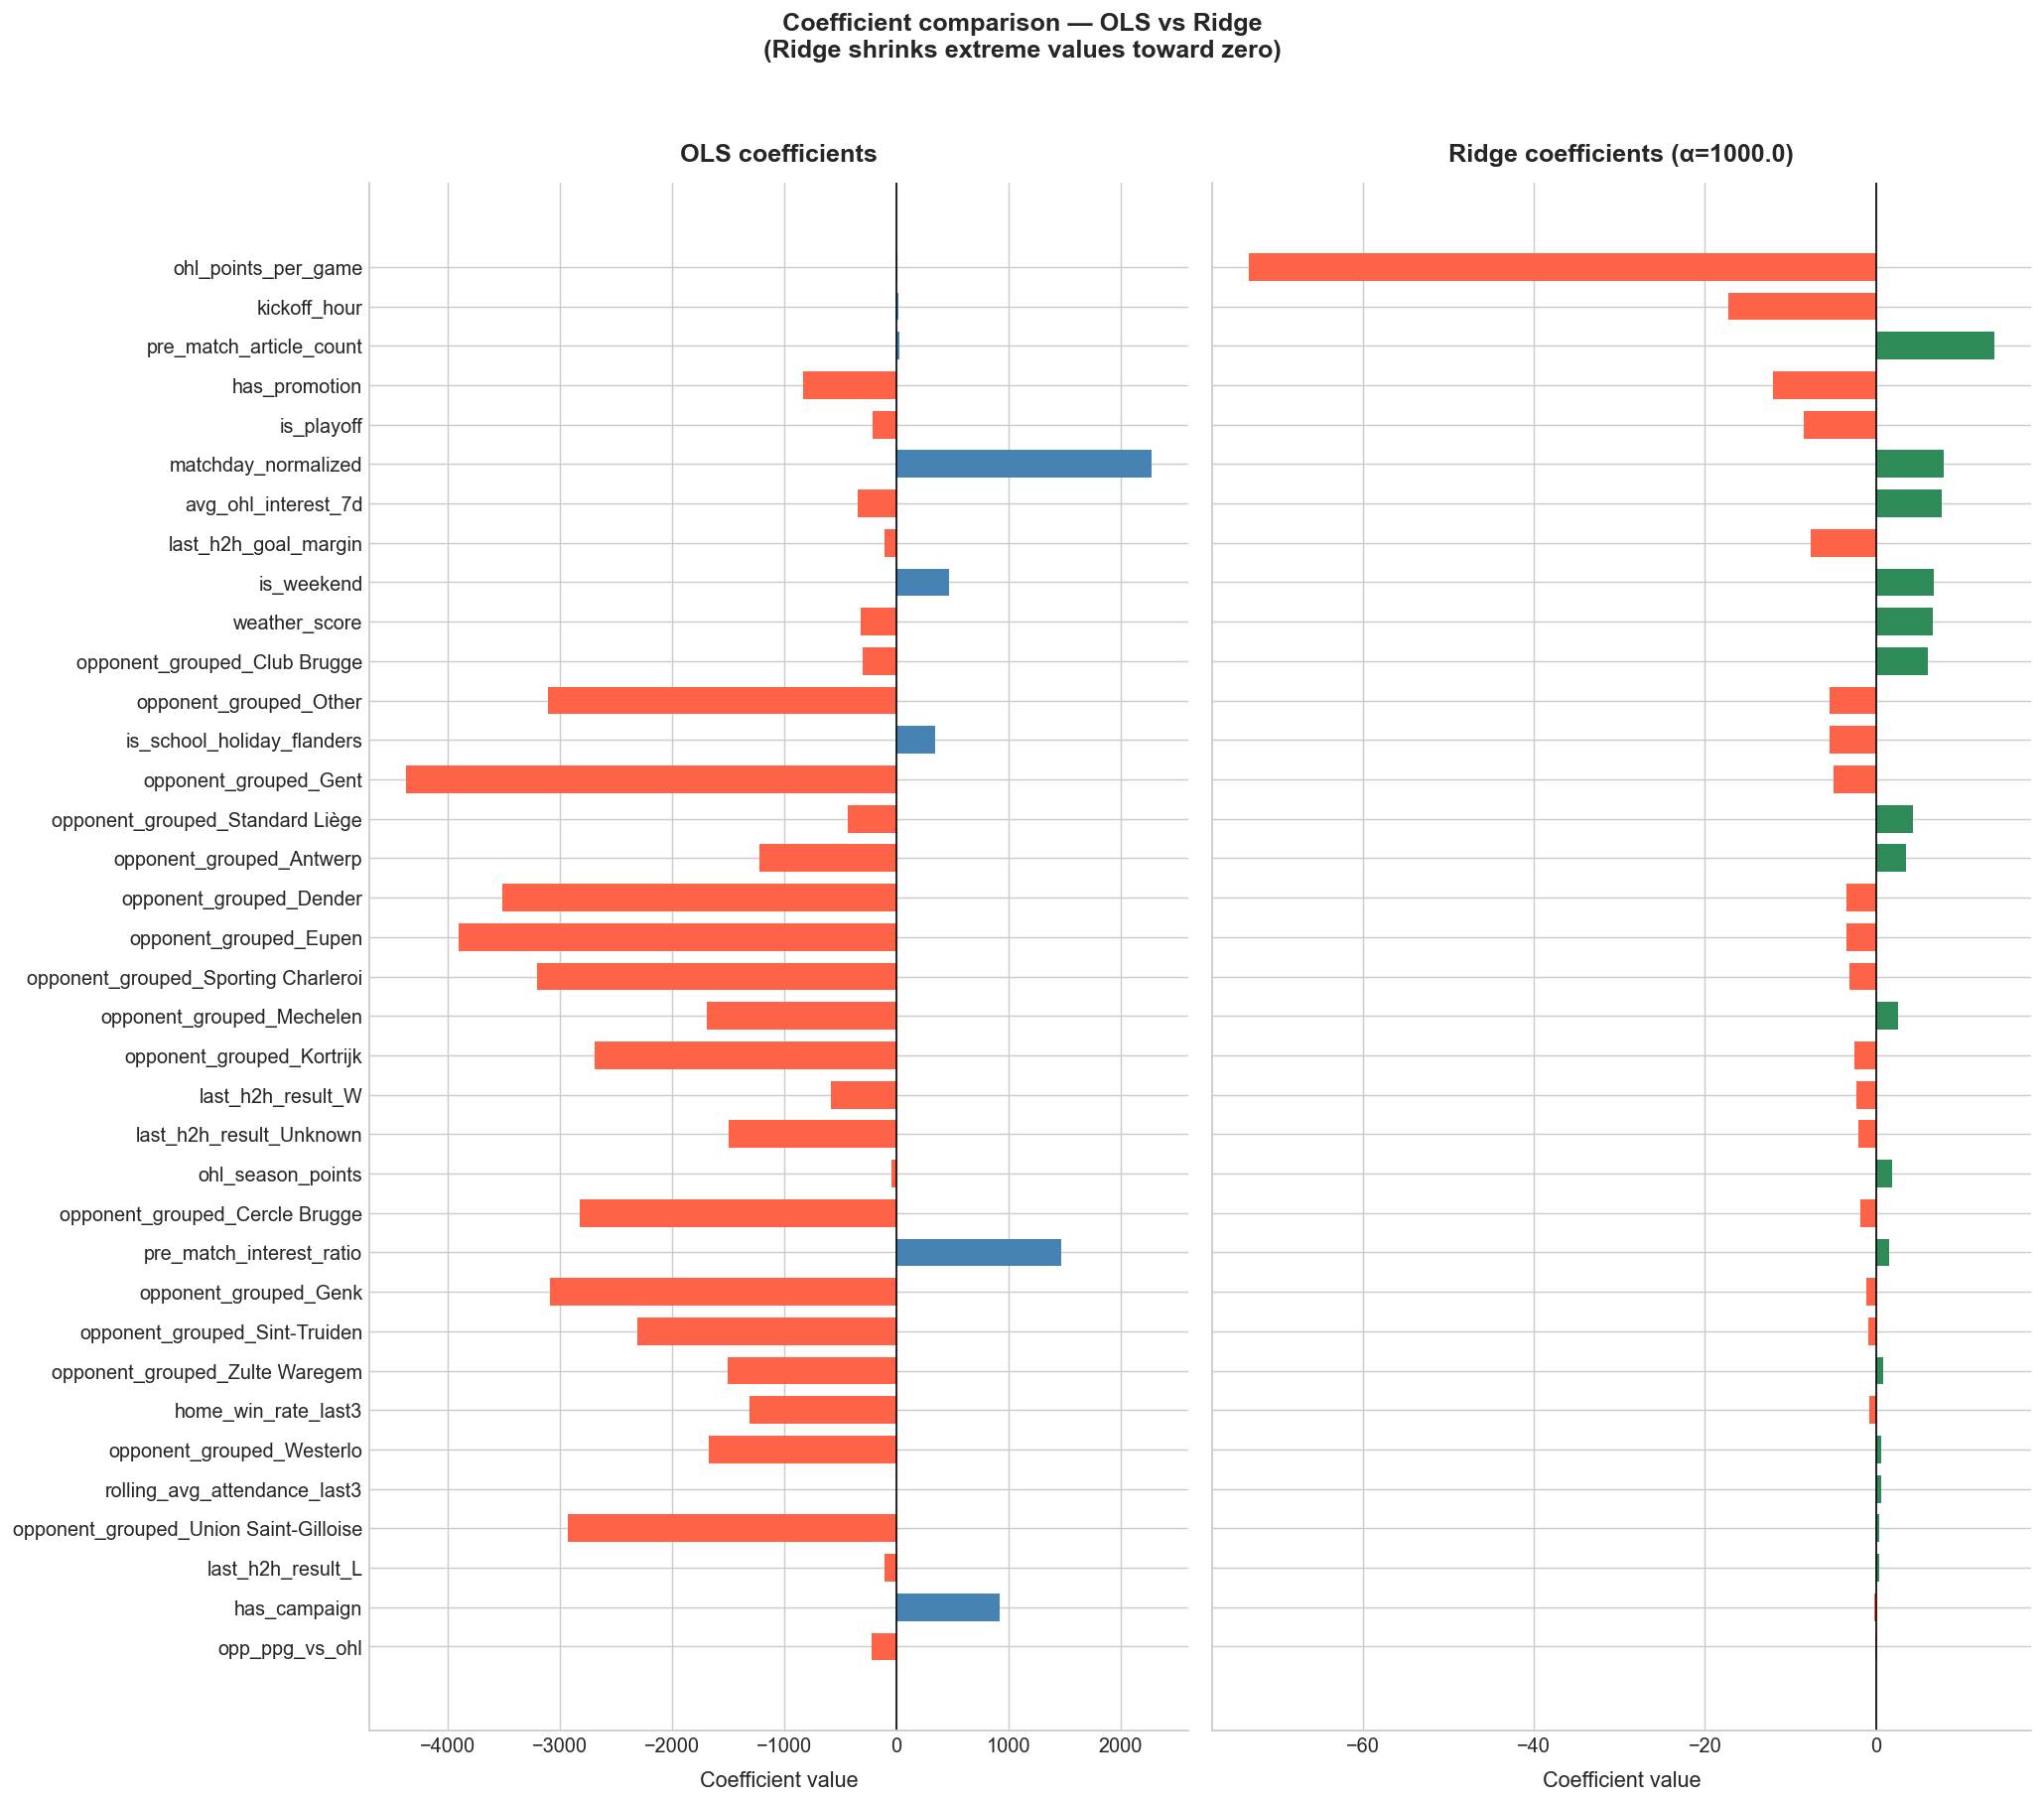

In [63]:
# --- Coefficient comparison: OLS vs Ridge ---
coef_compare = pd.DataFrame({
    'OLS':   ols.coef_,
    'Ridge': ridge.coef_,
}, index=X.columns).sort_values('Ridge', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(coef_compare) * 0.38)), sharey=True)

for ax, col, colour, title in zip(
    axes,
    ['OLS', 'Ridge'],
    ['steelblue', 'seagreen'],
    ['OLS coefficients', f'Ridge coefficients (α={ridge.alpha_})']
):
    colours = [colour if c >= 0 else 'tomato' for c in coef_compare[col]]
    ax.barh(coef_compare.index, coef_compare[col], color=colours, height=0.7)
    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_xlabel('Coefficient value')
    ax.set_title(title)

fig.suptitle(
    'Coefficient comparison — OLS vs Ridge\n(Ridge shrinks extreme values toward zero)',
    fontsize=14, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

## 8 — Lift Curve

A lift curve measures the **practical ranking value** of each model — independent of raw prediction accuracy.

Test matches are sorted by predicted attendance (highest to lowest). At each step we ask: *of the top X% of matches the model flags as high-attendance, what is their average actual attendance?* This is compared against the **baseline** — randomly selecting matches, which gives the overall mean regardless of selection size.

The area between the model curve and the baseline is the **lift**: how much smarter the model's ranking is than chance. This directly answers OHL's business question:
> *"If we allocate promotional budget to the matches our model ranks highest, how much better is that than spreading budget randomly?"*

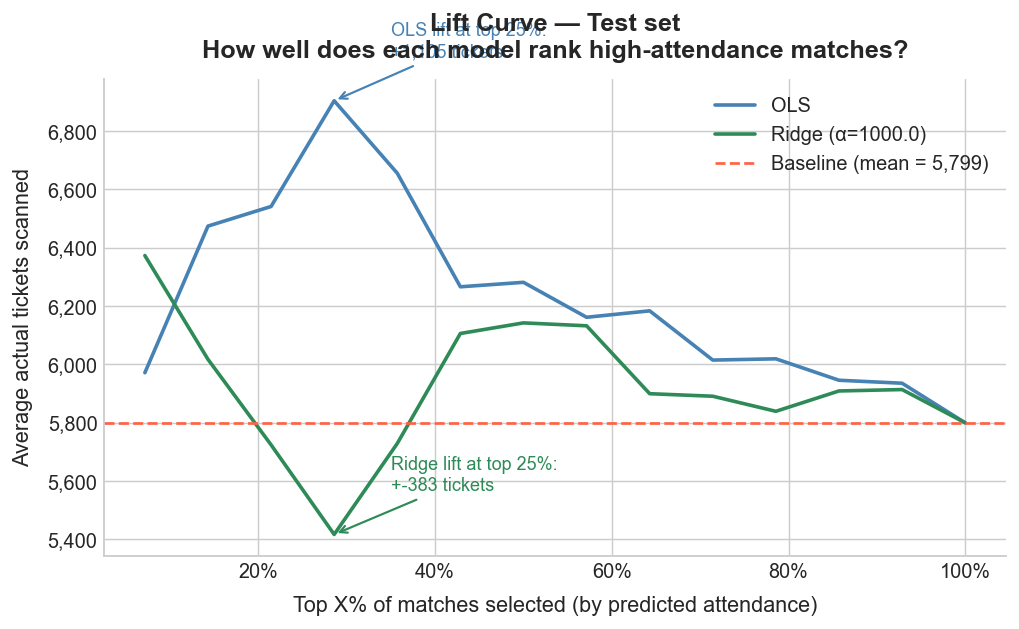

In [64]:
def lift_curve_data(y_true, y_pred):
    """
    Sort by predicted value descending, compute cumulative mean actual
    attendance at each step as a percentage of the dataset selected.
    Returns (pct_selected, cum_mean_actual).
    """
    order = np.argsort(y_pred)[::-1]
    y_sorted = np.array(y_true)[order]
    n = len(y_sorted)
    cum_means = np.cumsum(y_sorted) / np.arange(1, n + 1)
    pct = np.arange(1, n + 1) / n * 100
    return pct, cum_means


baseline = y_test.mean()

pct_ols,   mean_ols   = lift_curve_data(y_test, y_test_pred_ols)
pct_ridge, mean_ridge = lift_curve_data(y_test, y_test_pred_ridge)
pct_random = [0, 100]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(pct_ols,   mean_ols,   color='steelblue', linewidth=2,   label='OLS')
ax.plot(pct_ridge, mean_ridge, color='seagreen',  linewidth=2,   label=f'Ridge (α={ridge.alpha_})')
ax.axhline(baseline, color='tomato', linestyle='--', linewidth=1.5, label=f'Baseline (mean = {baseline:,.0f})')

ax.set_xlabel('Top X% of matches selected (by predicted attendance)')
ax.set_ylabel('Average actual tickets scanned')
ax.set_title('Lift Curve — Test set\nHow well does each model rank high-attendance matches?')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Annotate lift at top 25%
for pct_arr, mean_arr, colour, name in [
    (pct_ols, mean_ols, 'steelblue', 'OLS'),
    (pct_ridge, mean_ridge, 'seagreen', 'Ridge'),
]:
    idx = np.searchsorted(pct_arr, 25)
    lift_val = mean_arr[idx] - baseline
    ax.annotate(
        f'{name} lift at top 25%:\n+{lift_val:,.0f} tickets',
        xy=(pct_arr[idx], mean_arr[idx]),
        xytext=(35, mean_arr[idx] + 150),
        fontsize=10,
        color=colour,
        arrowprops=dict(arrowstyle='->', color=colour, lw=1.2),
    )

plt.tight_layout()
plt.show()